In [140]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.model_selection import TimeSeriesSplit

from xgboost import XGBRegressor

import joblib
import warnings

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

pd.set_option("display.max_columns", None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [141]:
DATA_PATH = "wheat_market_1000.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

print("\nFirst 5 Rows:")
display(df.head())

print("\nColumn Names:")
print(df.columns.tolist())

Dataset loaded successfully!
Dataset Shape: (1000, 9)

First 5 Rows:


,date,location,crop,price_per_kg,temperature_c,rainfall_mm,market_arrivals_kg,festival_flag,demand_kg
0,2023-01-01,Delhi,Wheat,29.6,16.1,0.0,2848,0,2116
1,2023-01-02,Delhi,Wheat,30.3,16.1,1.6,2927,0,2167
2,2023-01-03,Delhi,Wheat,30.0,15.8,0.0,2953,0,2211
3,2023-01-04,Delhi,Wheat,30.1,15.6,0.0,3001,0,2238
4,2023-01-05,Delhi,Wheat,30.3,15.8,0.0,3041,0,2286



Column Names:
['date', 'location', 'crop', 'price_per_kg', 'temperature_c', 'rainfall_mm', 'market_arrivals_kg', 'festival_flag', 'demand_kg']


In [142]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

print("\nDataset Info:")
df.info()

Number of Rows: 1000
Number of Columns: 9

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   date                1000 non-null   str    
 1   location            1000 non-null   str    
 2   crop                1000 non-null   str    
 3   price_per_kg        1000 non-null   float64
 4   temperature_c       1000 non-null   float64
 5   rainfall_mm         1000 non-null   float64
 6   market_arrivals_kg  1000 non-null   int64  
 7   festival_flag       1000 non-null   int64  
 8   demand_kg           1000 non-null   int64  
dtypes: float64(3), int64(3), str(3)
memory usage: 91.8 KB


In [143]:
print("Data Types:\n")

display(
    pd.DataFrame(
        {
            "Column": df.columns,
            "Data Type": df.dtypes.values
        }
    )
)

Data Types:



,Column,Data Type
0,date,str
1,location,str
2,crop,str
3,price_per_kg,float64
4,temperature_c,float64
5,rainfall_mm,float64
6,market_arrivals_kg,int64
7,festival_flag,int64
8,demand_kg,int64


In [144]:
missing_values = df.isnull().sum()

missing_percentage = (
    missing_values / len(df)
) * 100

missing_report = pd.DataFrame(
    {
        "Missing Values": missing_values,
        "Missing Percentage": missing_percentage
    }
)

display(missing_report)

,Missing Values,Missing Percentage
date,0,0.0
location,0,0.0
crop,0,0.0
price_per_kg,0,0.0
temperature_c,0,0.0
rainfall_mm,0,0.0
market_arrivals_kg,0,0.0
festival_flag,0,0.0
demand_kg,0,0.0


In [145]:
duplicate_count = df.duplicated().sum()

print("Number of Duplicate Rows:", duplicate_count)

Number of Duplicate Rows: 0


In [146]:
print("Unique Locations:")
print(df["location"].unique())

print("\nNumber of Locations:")
print(df["location"].nunique())

print("\nUnique Crops:")
print(df["crop"].unique())

print("\nNumber of Crops:")
print(df["crop"].nunique())

Unique Locations:
<ArrowStringArray>
[    'Delhi',     'Noida', 'Ghaziabad',  'Gurugram', 'Faridabad',   'Sonipat',
   'Panipat',    'Meerut',    'Rohtak']
Length: 9, dtype: str

Number of Locations:
9

Unique Crops:
<ArrowStringArray>
['Wheat']
Length: 1, dtype: str

Number of Crops:
1


In [147]:
df_temp = df.copy()

df_temp["date"] = pd.to_datetime(
    df_temp["date"],
    errors="coerce"
)

print("Minimum Date:", df_temp["date"].min())
print("Maximum Date:", df_temp["date"].max())

Minimum Date: 2023-01-01 00:00:00
Maximum Date: 2025-09-26 00:00:00


In [148]:
display(
    df.describe(include="all")
)

,date,location,crop,price_per_kg,temperature_c,rainfall_mm,market_arrivals_kg,festival_flag,demand_kg
count,1000,1000,1000,1000.00000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
unique,1000,9,1,NaN,NaN,NaN,NaN,NaN,NaN
top,2023-01-01,Delhi,Wheat,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,120,1000,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,31.71250,23.690300,0.211200,1800.604000,0.10000,1364.265000
std,NaN,NaN,NaN,1.89881,5.457239,0.472269,572.903718,0.30015,440.377517
min,NaN,NaN,NaN,27.50000,15.400000,0.000000,1083.000000,0.00000,811.000000
25%,NaN,NaN,NaN,30.20000,17.800000,0.000000,1446.500000,0.00000,1090.750000
50%,NaN,NaN,NaN,31.80000,24.250000,0.000000,1647.500000,0.00000,1243.000000
75%,NaN,NaN,NaN,33.10000,28.800000,0.000000,1873.500000,0.00000,1423.500000


In [149]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print("Standardized Columns:")
print(df.columns.tolist())

Standardized Columns:
['date', 'location', 'crop', 'price_per_kg', 'temperature_c', 'rainfall_mm', 'market_arrivals_kg', 'festival_flag', 'demand_kg']


In [150]:
df["date"] = pd.to_datetime(
    df["date"],
    errors="coerce"
)

print("Date converted successfully.")

print("\nInvalid Dates:")
print(df["date"].isnull().sum())

Date converted successfully.

Invalid Dates:
0


In [151]:
before_rows = len(df)

df = df.dropna(
    subset=["date"]
).copy()

after_rows = len(df)

print("Rows Before:", before_rows)
print("Rows After:", after_rows)
print("Removed Rows:", before_rows - after_rows)

Rows Before: 1000
Rows After: 1000
Removed Rows: 0


In [152]:
before_rows = len(df)

df = df.drop_duplicates().copy()

after_rows = len(df)

print("Duplicates removed:", before_rows - after_rows)
print("Remaining Rows:", after_rows)

Duplicates removed: 0
Remaining Rows: 1000


In [153]:
invalid_report = pd.DataFrame(
    {
        "Negative Values": [
            (df["price_per_kg"] < 0).sum(),
            (df["rainfall_mm"] < 0).sum(),
            (df["market_arrivals_kg"] < 0).sum(),
            (df["demand_kg"] < 0).sum()
        ]
    },
    index=[
        "price_per_kg",
        "rainfall_mm",
        "market_arrivals_kg",
        "demand_kg"
    ]
)

display(invalid_report)

,Negative Values
price_per_kg,0
rainfall_mm,0
market_arrivals_kg,0
demand_kg,0


In [154]:
before_rows = len(df)

df = df[
    (df["price_per_kg"] >= 0) &
    (df["rainfall_mm"] >= 0) &
    (df["market_arrivals_kg"] >= 0) &
    (df["demand_kg"] >= 0)
].copy()

after_rows = len(df)

print("Rows removed due to invalid values:")
print(before_rows - after_rows)

print("Remaining Rows:", after_rows)

Rows removed due to invalid values:
0
Remaining Rows: 1000


In [155]:
numeric_columns = [
    "price_per_kg",
    "temperature_c",
    "rainfall_mm",
    "market_arrivals_kg",
    "festival_flag"
]

categorical_columns = [
    "location",
    "crop"
]

for col in numeric_columns:
    df[col] = df[col].fillna(
        df[col].median()
    )

for col in categorical_columns:
    df[col] = df[col].fillna(
        df[col].mode()[0]
    )

# Do not fabricate target demand values
df = df.dropna(
    subset=["demand_kg"]
).copy()

print("Missing Values After Cleaning:")
display(df.isnull().sum())

Missing Values After Cleaning:


date                  0
location              0
crop                  0
price_per_kg          0
temperature_c         0
rainfall_mm           0
market_arrivals_kg    0
festival_flag         0
demand_kg             0
dtype: int64

In [156]:
df = df.sort_values(
    by=[
        "location",
        "crop",
        "date"
    ]
).reset_index(drop=True)

display(df.head())

print("Data sorted successfully!")

,date,location,crop,price_per_kg,temperature_c,rainfall_mm,market_arrivals_kg,festival_flag,demand_kg
0,2023-01-01,Delhi,Wheat,29.6,16.1,0.0,2848,0,2116
1,2023-01-02,Delhi,Wheat,30.3,16.1,1.6,2927,0,2167
2,2023-01-03,Delhi,Wheat,30.0,15.8,0.0,2953,0,2211
3,2023-01-04,Delhi,Wheat,30.1,15.6,0.0,3001,0,2238
4,2023-01-05,Delhi,Wheat,30.3,15.8,0.0,3041,0,2286


Data sorted successfully!


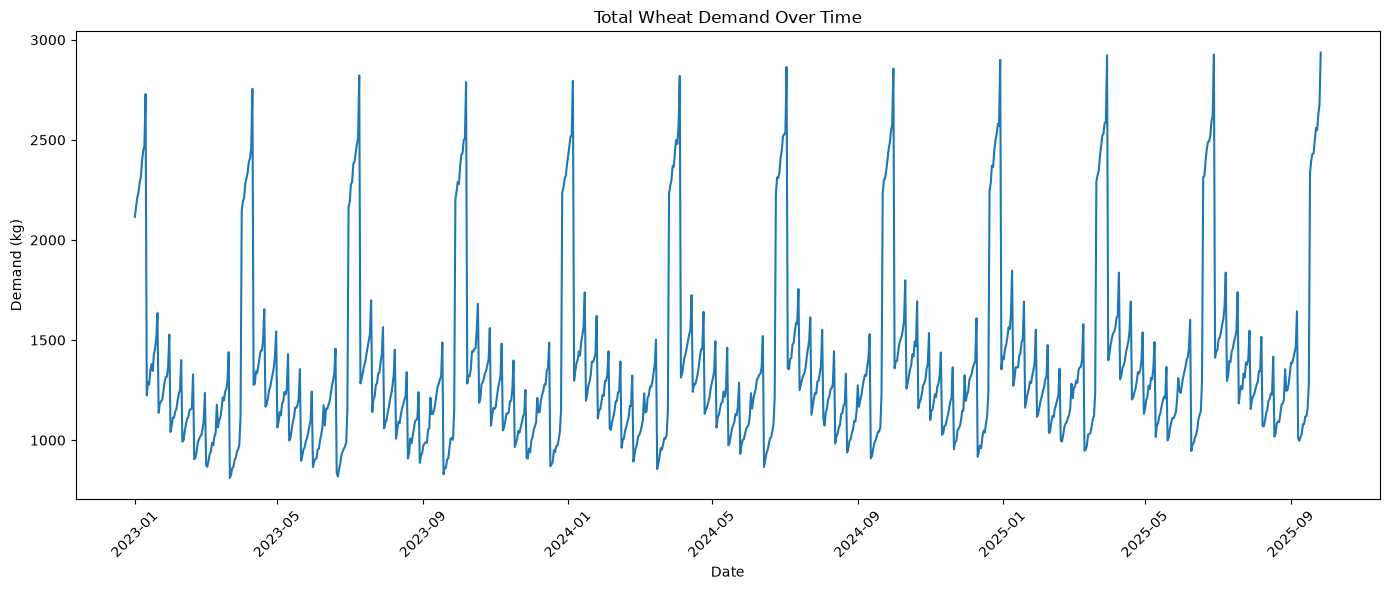

In [157]:
daily_demand = (
    df.groupby("date")["demand_kg"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(14, 6))

plt.plot(
    daily_demand["date"],
    daily_demand["demand_kg"]
)

plt.title("Total Wheat Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Demand (kg)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

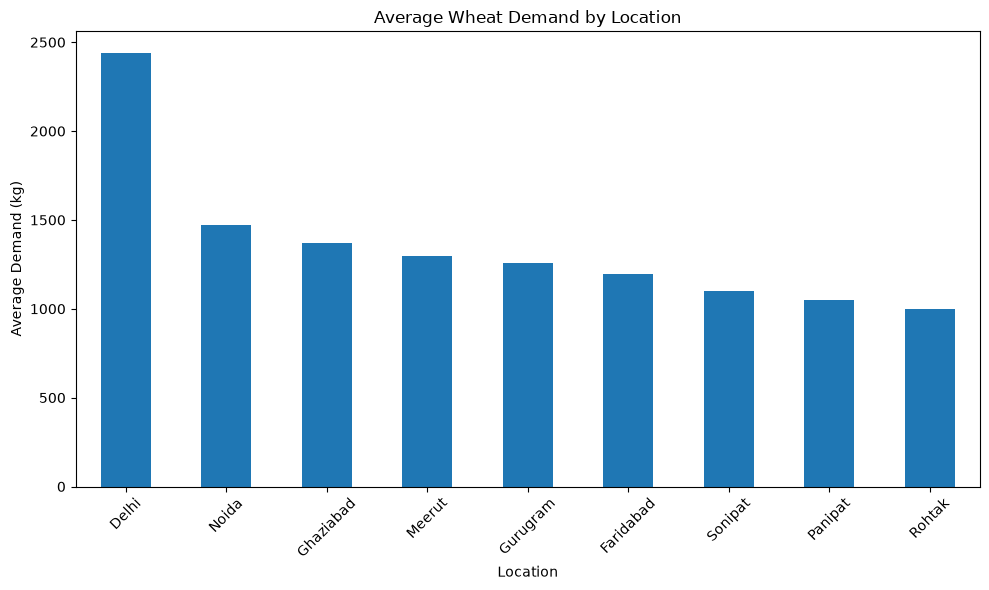

In [158]:
location_demand = (
    df.groupby("location")["demand_kg"]
    .mean()
    .sort_values(
        ascending=False
    )
)

plt.figure(figsize=(10, 6))

location_demand.plot(
    kind="bar"
)

plt.title("Average Wheat Demand by Location")
plt.xlabel("Location")
plt.ylabel("Average Demand (kg)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

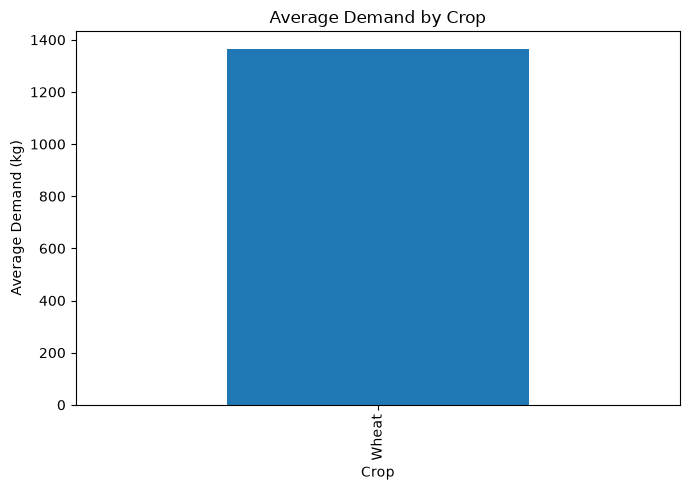

In [159]:
crop_demand = (
    df.groupby("crop")["demand_kg"]
    .mean()
)

plt.figure(figsize=(7, 5))

crop_demand.plot(
    kind="bar"
)

plt.title("Average Demand by Crop")
plt.xlabel("Crop")
plt.ylabel("Average Demand (kg)")

plt.tight_layout()

plt.show()

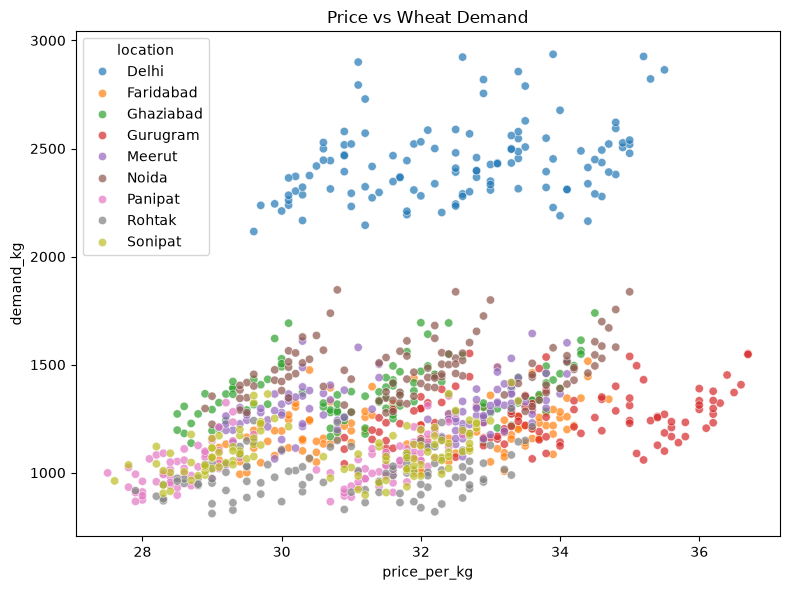

In [160]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="price_per_kg",
    y="demand_kg",
    hue="location",
    alpha=0.7
)

plt.title("Price vs Wheat Demand")

plt.tight_layout()

plt.show()

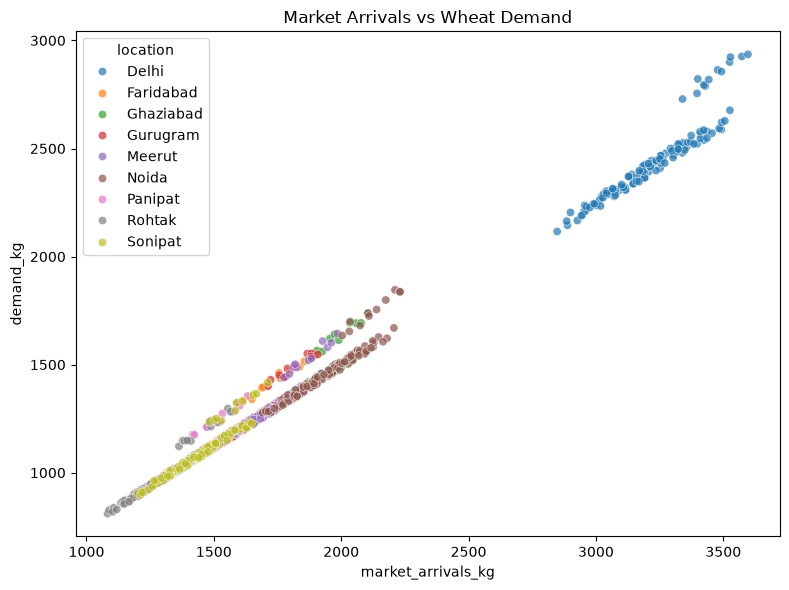

In [161]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="market_arrivals_kg",
    y="demand_kg",
    hue="location",
    alpha=0.7
)

plt.title("Market Arrivals vs Wheat Demand")

plt.tight_layout()

plt.show()

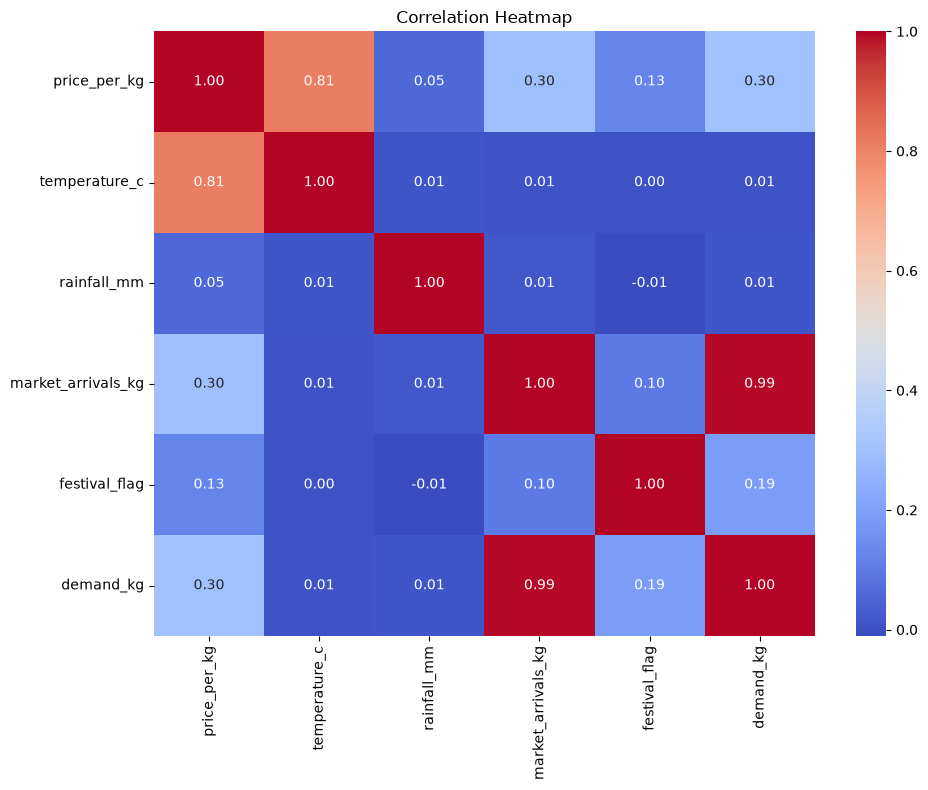

In [162]:
numerical_columns = df.select_dtypes(
    include=np.number
).columns

correlation_matrix = df[
    numerical_columns
].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.show()

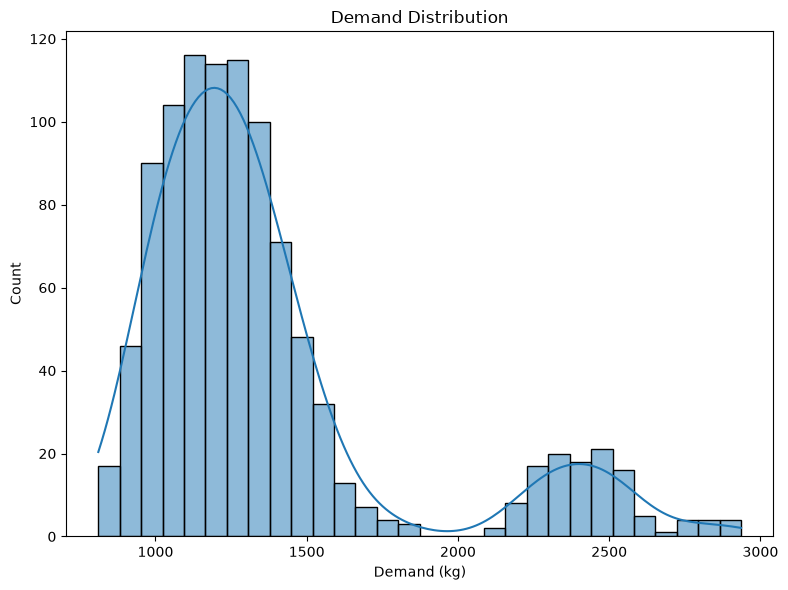

In [163]:
plt.figure(figsize=(8, 6))

sns.histplot(
    df["demand_kg"],
    kde=True,
    bins=30
)

plt.title("Demand Distribution")
plt.xlabel("Demand (kg)")

plt.tight_layout()

plt.show()

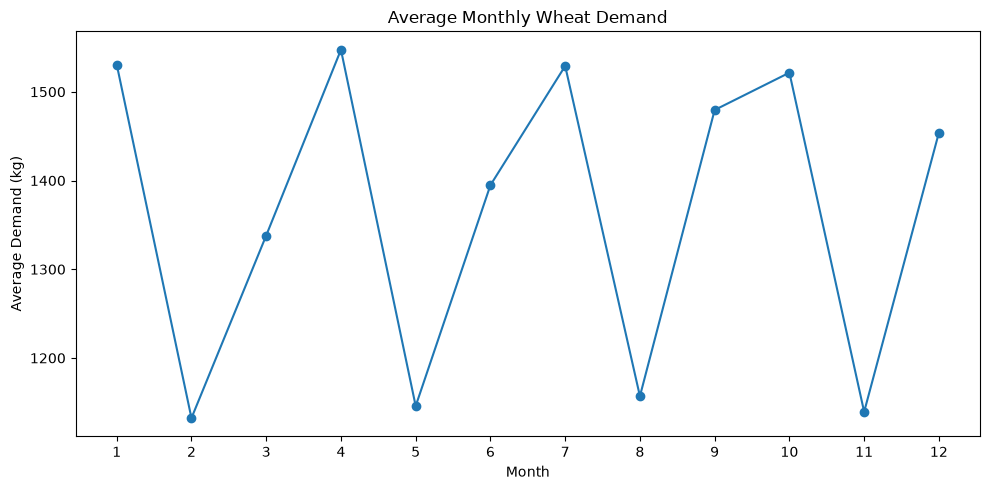

In [164]:
monthly_demand = (
    df.assign(
        month=df["date"].dt.month
    )
    .groupby("month")["demand_kg"]
    .mean()
)

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_demand.index,
    monthly_demand.values,
    marker="o"
)

plt.title("Average Monthly Wheat Demand")
plt.xlabel("Month")
plt.ylabel("Average Demand (kg)")

plt.xticks(
    range(1, 13)
)

plt.tight_layout()

plt.show()

In [165]:
df["year"] = df["date"].dt.year

df["month"] = df["date"].dt.month

df["day"] = df["date"].dt.day

df["day_of_week"] = df["date"].dt.dayofweek

df["day_of_year"] = df["date"].dt.dayofyear

df["week_of_year"] = (
    df["date"]
    .dt.isocalendar()
    .week
    .astype(int)
)

df["quarter"] = df["date"].dt.quarter

df["is_weekend"] = (
    df["day_of_week"] >= 5
).astype(int)

display(df.head())

,date,location,crop,price_per_kg,temperature_c,rainfall_mm,market_arrivals_kg,festival_flag,demand_kg,year,month,day,day_of_week,day_of_year,week_of_year,quarter,is_weekend
0,2023-01-01,Delhi,Wheat,29.6,16.1,0.0,2848,0,2116,2023,1,1,6,1,52,1,1
1,2023-01-02,Delhi,Wheat,30.3,16.1,1.6,2927,0,2167,2023,1,2,0,2,1,1,0
2,2023-01-03,Delhi,Wheat,30.0,15.8,0.0,2953,0,2211,2023,1,3,1,3,1,1,0
3,2023-01-04,Delhi,Wheat,30.1,15.6,0.0,3001,0,2238,2023,1,4,2,4,1,1,0
4,2023-01-05,Delhi,Wheat,30.3,15.8,0.0,3041,0,2286,2023,1,5,3,5,1,1,0


In [166]:
df["month_sin"] = np.sin(
    2 * np.pi * df["month"] / 12
)

df["month_cos"] = np.cos(
    2 * np.pi * df["month"] / 12
)

df["day_of_week_sin"] = np.sin(
    2 * np.pi * df["day_of_week"] / 7
)

df["day_of_week_cos"] = np.cos(
    2 * np.pi * df["day_of_week"] / 7
)

print("Cyclical features created successfully.")

display(
    df[
        [
            "month",
            "month_sin",
            "month_cos",
            "day_of_week",
            "day_of_week_sin",
            "day_of_week_cos"
        ]
    ].head()
)

Cyclical features created successfully.


,month,month_sin,month_cos,day_of_week,day_of_week_sin,day_of_week_cos
0,1,0.5,0.866025,6,-0.781831,0.623490
1,1,0.5,0.866025,0,0.000000,1.000000
2,1,0.5,0.866025,1,0.781831,0.623490
3,1,0.5,0.866025,2,0.974928,-0.222521
4,1,0.5,0.866025,3,0.433884,-0.900969


In [167]:
lag_columns = [
    1,
    2,
    3,
    7,
    14,
    30
]

for lag in lag_columns:

    df[f"lag_{lag}"] = (
        df.groupby(
            ["location", "crop"]
        )["demand_kg"]
        .shift(lag)
    )

print("Lag features created successfully.")

display(
    df.head()
)

Lag features created successfully.


,date,location,crop,price_per_kg,temperature_c,rainfall_mm,market_arrivals_kg,festival_flag,demand_kg,year,month,day,day_of_week,day_of_year,week_of_year,quarter,is_weekend,month_sin,month_cos,day_of_week_sin,day_of_week_cos,lag_1,lag_2,lag_3,lag_7,lag_14,lag_30
0,2023-01-01,Delhi,Wheat,29.6,16.1,0.0,2848,0,2116,2023,1,1,6,1,52,1,1,0.5,0.866025,-0.781831,0.623490,NaN,NaN,NaN,NaN,NaN,NaN
1,2023-01-02,Delhi,Wheat,30.3,16.1,1.6,2927,0,2167,2023,1,2,0,2,1,1,0,0.5,0.866025,0.000000,1.000000,2116.0,NaN,NaN,NaN,NaN,NaN
2,2023-01-03,Delhi,Wheat,30.0,15.8,0.0,2953,0,2211,2023,1,3,1,3,1,1,0,0.5,0.866025,0.781831,0.623490,2167.0,2116.0,NaN,NaN,NaN,NaN
3,2023-01-04,Delhi,Wheat,30.1,15.6,0.0,3001,0,2238,2023,1,4,2,4,1,1,0,0.5,0.866025,0.974928,-0.222521,2211.0,2167.0,2116.0,NaN,NaN,NaN
4,2023-01-05,Delhi,Wheat,30.3,15.8,0.0,3041,0,2286,2023,1,5,3,5,1,1,0,0.5,0.866025,0.433884,-0.900969,2238.0,2211.0,2167.0,NaN,NaN,NaN


In [168]:
grouped_demand = (
    df.groupby(
        ["location", "crop"]
    )["demand_kg"]
)

df["rolling_mean_7"] = (
    grouped_demand
    .transform(
        lambda x:
        x.shift(1)
        .rolling(
            window=7,
            min_periods=7
        )
        .mean()
    )
)

df["rolling_mean_14"] = (
    grouped_demand
    .transform(
        lambda x:
        x.shift(1)
        .rolling(
            window=14,
            min_periods=14
        )
        .mean()
    )
)

df["rolling_mean_30"] = (
    grouped_demand
    .transform(
        lambda x:
        x.shift(1)
        .rolling(
            window=30,
            min_periods=30
        )
        .mean()
    )
)

df["rolling_std_7"] = (
    grouped_demand
    .transform(
        lambda x:
        x.shift(1)
        .rolling(
            window=7,
            min_periods=7
        )
        .std()
    )
)

df["rolling_std_30"] = (
    grouped_demand
    .transform(
        lambda x:
        x.shift(1)
        .rolling(
            window=30,
            min_periods=30
        )
        .std()
    )
)

print("Rolling features created successfully.")

Rolling features created successfully.


In [169]:
feature_nan_report = df.isnull().sum()

display(
    feature_nan_report[
        feature_nan_report > 0
    ]
)

lag_1                9
lag_2               18
lag_3               27
lag_7               63
lag_14             126
lag_30             270
rolling_mean_7      63
rolling_mean_14    126
rolling_mean_30    270
rolling_std_7       63
rolling_std_30     270
dtype: int64

In [170]:
before_rows = len(df)

lag_rolling_features = [
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_7",
    "lag_14",
    "lag_30",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_30",
    "rolling_std_7",
    "rolling_std_30"
]

df_model = df.dropna(
    subset=lag_rolling_features
).copy()

after_rows = len(df_model)

print("Rows Before:", before_rows)
print("Rows After:", after_rows)
print("Rows Removed:", before_rows - after_rows)

Rows Before: 1000
Rows After: 730
Rows Removed: 270


In [171]:
df_model = df_model.sort_values(
    by="date"
).reset_index(drop=True)

print("Final Modeling Dataset Shape:")
print(df_model.shape)

display(df_model.head())

Final Modeling Dataset Shape:
(730, 32)


,date,location,crop,price_per_kg,temperature_c,rainfall_mm,market_arrivals_kg,festival_flag,demand_kg,year,month,day,day_of_week,day_of_year,week_of_year,quarter,is_weekend,month_sin,month_cos,day_of_week_sin,day_of_week_cos,lag_1,lag_2,lag_3,lag_7,lag_14,lag_30,rolling_mean_7,rolling_mean_14,rolling_mean_30,rolling_std_7,rolling_std_30
0,2023-09-28,Delhi,Wheat,32.3,25.9,0.0,2900,0,2204,2023,9,28,3,271,39,3,0,-1.000000,-1.836970e-16,0.433884,-0.900969,2822.0,2505.0,2478.0,2290.0,2391.0,2116.0,2471.571429,2424.642857,2359.600000,169.873342,176.906677
1,2023-09-29,Delhi,Wheat,32.5,25.5,0.0,2989,0,2243,2023,9,29,4,272,39,3,0,-1.000000,-1.836970e-16,-0.433884,-0.900969,2204.0,2822.0,2505.0,2380.0,2409.0,2167.0,2459.285714,2411.285714,2362.533333,187.399497,173.423487
2,2023-09-30,Delhi,Wheat,32.6,25.3,0.0,3031,0,2290,2023,9,30,5,273,39,3,1,-1.000000,-1.836970e-16,-0.974928,-0.222521,2243.0,2204.0,2822.0,2391.0,2458.0,2211.0,2439.714286,2399.428571,2365.066667,203.520445,171.006943
3,2023-10-01,Delhi,Wheat,32.6,25.3,0.0,3072,0,2279,2023,10,1,6,274,39,4,1,-0.866025,5.000000e-01,-0.781831,0.623490,2290.0,2243.0,2204.0,2435.0,2755.0,2238.0,2425.285714,2387.428571,2367.700000,210.992665,169.150851
4,2023-10-02,Delhi,Wheat,32.8,25.2,0.0,3148,0,2367,2023,10,2,0,275,40,4,0,-0.866025,5.000000e-01,0.000000,1.000000,2279.0,2290.0,2243.0,2478.0,2164.0,2286.0,2403.000000,2353.428571,2369.066667,217.920475,168.229919


In [172]:
target_column = "demand_kg"

feature_columns = [
    "location",
    "crop",
    "price_per_kg",
    "temperature_c",
    "rainfall_mm",
    "market_arrivals_kg",
    "festival_flag",
    "year",
    "month",
    "day",
    "day_of_week",
    "day_of_year",
    "week_of_year",
    "quarter",
    "is_weekend",
    "month_sin",
    "month_cos",
    "day_of_week_sin",
    "day_of_week_cos",
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_7",
    "lag_14",
    "lag_30",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_30",
    "rolling_std_7",
    "rolling_std_30"
]

X = df_model[
    feature_columns
].copy()

y = df_model[
    target_column
].copy()

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (730, 30)
Target Shape: (730,)


In [173]:
n_rows = len(df_model)

train_end = int(
    n_rows * 0.70
)

validation_end = int(
    n_rows * 0.85
)

X_train = X.iloc[:train_end].copy()

X_val = X.iloc[
    train_end:validation_end
].copy()

X_test = X.iloc[
    validation_end:
].copy()


y_train = y.iloc[:train_end].copy()

y_val = y.iloc[
    train_end:validation_end
].copy()

y_test = y.iloc[
    validation_end:
].copy()


date_train = df_model["date"].iloc[
    :train_end
].copy()

date_val = df_model["date"].iloc[
    train_end:validation_end
].copy()

date_test = df_model["date"].iloc[
    validation_end:
].copy()


print("Train Shape:", X_train.shape)
print("Validation Shape:", X_val.shape)
print("Test Shape:", X_test.shape)

print("\nTrain Date Range:")
print(date_train.min(), "to", date_train.max())

print("\nValidation Date Range:")
print(date_val.min(), "to", date_val.max())

print("\nTest Date Range:")
print(date_test.min(), "to", date_test.max())

Train Shape: (510, 30)
Validation Shape: (110, 30)
Test Shape: (110, 30)

Train Date Range:
2023-09-28 00:00:00 to 2025-02-18 00:00:00

Validation Date Range:
2025-02-19 00:00:00 to 2025-06-08 00:00:00

Test Date Range:
2025-06-09 00:00:00 to 2025-09-26 00:00:00


In [174]:
categorical_features = [
    "location",
    "crop"
]

numerical_features = [
    col
    for col in feature_columns
    if col not in categorical_features
]

numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numerical_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [175]:
def safe_mape(y_true, y_pred):

    y_true = np.array(y_true)

    y_pred = np.array(y_pred)

    mask = y_true != 0

    if mask.sum() == 0:
        return np.nan

    return np.mean(
        np.abs(
            (
                y_true[mask] -
                y_pred[mask]
            )
            /
            y_true[mask]
        )
    ) * 100


def evaluate_model(
    y_true,
    y_pred
):

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    mape = safe_mape(
        y_true,
        y_pred
    )

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "MAPE": mape
    }


print("Evaluation function created successfully.")

Evaluation function created successfully.


In [176]:
baseline_val_pred = X_val[
    "lag_1"
].values

baseline_test_pred = X_test[
    "lag_1"
].values


baseline_val_metrics = evaluate_model(
    y_val,
    baseline_val_pred
)

baseline_test_metrics = evaluate_model(
    y_test,
    baseline_test_pred
)


print("Validation Metrics:")
print(baseline_val_metrics)

print("\nTest Metrics:")
print(baseline_test_metrics)

Validation Metrics:
{'MAE': 75.87272727272727, 'RMSE': np.float64(136.23629205438348), 'R2': 0.8827088533543807, 'MAPE': np.float64(5.675743498565684)}

Test Metrics:
{'MAE': 81.04545454545455, 'RMSE': np.float64(144.01133162485388), 'R2': 0.9226361530276981, 'MAPE': np.float64(5.5841088456591335)}


In [177]:
linear_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LinearRegression()
        )
    ]
)

print("Linear Regression pipeline created.")

Linear Regression pipeline created.


In [178]:
linear_model.fit(
    X_train,
    y_train
)

print("Linear Regression trained successfully.")

Linear Regression trained successfully.


In [179]:
lr_train_pred = linear_model.predict(
    X_train
)

lr_val_pred = linear_model.predict(
    X_val
)

lr_test_pred = linear_model.predict(
    X_test
)

print("Predictions generated successfully.")

Predictions generated successfully.


In [180]:
lr_train_metrics = evaluate_model(
    y_train,
    lr_train_pred
)

lr_val_metrics = evaluate_model(
    y_val,
    lr_val_pred
)

lr_test_metrics = evaluate_model(
    y_test,
    lr_test_pred
)


print("Training Metrics:")
print(lr_train_metrics)

print("\nValidation Metrics:")
print(lr_val_metrics)

print("\nTest Metrics:")
print(lr_test_metrics)

Training Metrics:
{'MAE': 10.165820226657688, 'RMSE': np.float64(13.426478640929593), 'R2': 0.9990312505008963, 'MAPE': np.float64(0.7255965919074695)}

Validation Metrics:
{'MAE': 12.099294019760231, 'RMSE': np.float64(16.573751781765278), 'R2': 0.998264113751325, 'MAPE': np.float64(0.8518554569154738)}

Test Metrics:
{'MAE': 13.304772632526388, 'RMSE': np.float64(17.553943994448343), 'R2': 0.9988505392620907, 'MAPE': np.float64(0.8704464545670152)}


In [181]:
xgb_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            XGBRegressor(
                n_estimators=300,
                learning_rate=0.05,
                max_depth=4,
                min_child_weight=5,
                subsample=0.8,
                colsample_bytree=0.8,
                reg_alpha=0.1,
                reg_lambda=1.0,
                random_state=RANDOM_STATE,
                objective="reg:squarederror",
                n_jobs=-1
            )
        )
    ]
)

print("XGBoost pipeline created.")

XGBoost pipeline created.


In [182]:
xgb_model.fit(
    X_train,
    y_train
)

print("XGBoost trained successfully.")

XGBoost trained successfully.


In [183]:
xgb_train_pred = xgb_model.predict(
    X_train
)

xgb_val_pred = xgb_model.predict(
    X_val
)

xgb_test_pred = xgb_model.predict(
    X_test
)

print("XGBoost predictions generated.")

XGBoost predictions generated.


In [184]:
xgb_train_metrics = evaluate_model(
    y_train,
    xgb_train_pred
)

xgb_val_metrics = evaluate_model(
    y_val,
    xgb_val_pred
)

xgb_test_metrics = evaluate_model(
    y_test,
    xgb_test_pred
)


print("Training Metrics:")
print(xgb_train_metrics)

print("\nValidation Metrics:")
print(xgb_val_metrics)

print("\nTest Metrics:")
print(xgb_test_metrics)

Training Metrics:
{'MAE': 5.303865909576416, 'RMSE': np.float64(6.705673195812126), 'R2': 0.9997583627700806, 'MAPE': np.float64(0.4095807510431801)}

Validation Metrics:
{'MAE': 16.230077743530273, 'RMSE': np.float64(25.09231491070772), 'R2': 0.9960210919380188, 'MAPE': np.float64(1.1336292976145192)}

Test Metrics:
{'MAE': 21.211944580078125, 'RMSE': np.float64(30.587567804570842), 'R2': 0.9965099096298218, 'MAPE': np.float64(1.3491912041158949)}


In [185]:
tscv = TimeSeriesSplit(
    n_splits=5
)

print(tscv)

TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None)


In [186]:
lr_cv_results = []

for fold, (
    train_index,
    val_index
) in enumerate(
    tscv.split(X_train),
    start=1
):

    X_fold_train = X_train.iloc[
        train_index
    ]

    X_fold_val = X_train.iloc[
        val_index
    ]

    y_fold_train = y_train.iloc[
        train_index
    ]

    y_fold_val = y_train.iloc[
        val_index
    ]

    fold_model = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "model",
                LinearRegression()
            )
        ]
    )

    fold_model.fit(
        X_fold_train,
        y_fold_train
    )

    fold_pred = fold_model.predict(
        X_fold_val
    )

    metrics = evaluate_model(
        y_fold_val,
        fold_pred
    )

    metrics["Fold"] = fold

    lr_cv_results.append(
        metrics
    )


lr_cv_df = pd.DataFrame(
    lr_cv_results
)

display(lr_cv_df)

print("\nAverage CV Results:")
display(
    lr_cv_df[
        ["MAE", "RMSE", "R2"]
    ].mean()
)

,MAE,RMSE,R2,MAPE,Fold
0,915.697196,948.682720,-3.991314,72.147187,1
1,14.783408,18.705891,0.998167,1.110367,2
2,23.625210,27.581538,0.996012,1.825991,3
3,12.418003,15.975659,0.998610,0.875827,4
4,36.334781,152.650754,0.872541,2.182927,5



Average CV Results:


MAE     200.571719
RMSE    232.719312
R2       -0.025197
dtype: float64

In [187]:
xgb_cv_results = []

for fold, (
    train_index,
    val_index
) in enumerate(
    tscv.split(X_train),
    start=1
):

    X_fold_train = X_train.iloc[
        train_index
    ]

    X_fold_val = X_train.iloc[
        val_index
    ]

    y_fold_train = y_train.iloc[
        train_index
    ]

    y_fold_val = y_train.iloc[
        val_index
    ]

    fold_model = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "model",
                XGBRegressor(
                    n_estimators=300,
                    learning_rate=0.05,
                    max_depth=4,
                    min_child_weight=5,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    reg_alpha=0.1,
                    reg_lambda=1.0,
                    random_state=RANDOM_STATE,
                    objective="reg:squarederror",
                    n_jobs=-1
                )
            )
        ]
    )

    fold_model.fit(
        X_fold_train,
        y_fold_train
    )

    fold_pred = fold_model.predict(
        X_fold_val
    )

    metrics = evaluate_model(
        y_fold_val,
        fold_pred
    )

    metrics["Fold"] = fold

    xgb_cv_results.append(
        metrics
    )


xgb_cv_df = pd.DataFrame(
    xgb_cv_results
)

display(xgb_cv_df)

print("\nAverage CV Results:")
display(
    xgb_cv_df[
        ["MAE", "RMSE", "R2"]
    ].mean()
)

,MAE,RMSE,R2,MAPE,Fold
0,213.731003,226.215165,0.716197,17.432982,1
1,19.728659,30.349520,0.995175,1.374082,2
2,18.755659,30.194247,0.995221,1.292521,3
3,15.722780,22.082358,0.997344,1.063956,4
4,21.405556,29.964198,0.995089,1.445117,5



Average CV Results:


MAE     57.868731
RMSE    67.761098
R2       0.939805
dtype: float64

In [188]:
comparison_results = pd.DataFrame(
    [
        {
            "Model": "Baseline",
            "CV MAE": np.nan,
            "CV RMSE": np.nan,
            "CV R2": np.nan,
            "Validation RMSE": baseline_val_metrics["RMSE"],
            "Test MAE": baseline_test_metrics["MAE"],
            "Test RMSE": baseline_test_metrics["RMSE"],
            "Test R2": baseline_test_metrics["R2"]
        },
        {
            "Model": "Linear Regression",
            "CV MAE": lr_cv_df["MAE"].mean(),
            "CV RMSE": lr_cv_df["RMSE"].mean(),
            "CV R2": lr_cv_df["R2"].mean(),
            "Validation RMSE": lr_val_metrics["RMSE"],
            "Test MAE": lr_test_metrics["MAE"],
            "Test RMSE": lr_test_metrics["RMSE"],
            "Test R2": lr_test_metrics["R2"]
        },
        {
            "Model": "XGBoost",
            "CV MAE": xgb_cv_df["MAE"].mean(),
            "CV RMSE": xgb_cv_df["RMSE"].mean(),
            "CV R2": xgb_cv_df["R2"].mean(),
            "Validation RMSE": xgb_val_metrics["RMSE"],
            "Test MAE": xgb_test_metrics["MAE"],
            "Test RMSE": xgb_test_metrics["RMSE"],
            "Test R2": xgb_test_metrics["R2"]
        }
    ]
)

comparison_results = comparison_results.sort_values(
    by="Validation RMSE"
).reset_index(
    drop=True
)

display(comparison_results)

,Model,CV MAE,CV RMSE,CV R2,Validation RMSE,Test MAE,Test RMSE,Test R2
0,Linear Regression,200.571719,232.719312,-0.025197,16.573752,13.304773,17.553944,0.998851
1,XGBoost,57.868731,67.761098,0.939805,25.092315,21.211945,30.587568,0.996510
2,Baseline,NaN,NaN,NaN,136.236292,81.045455,144.011332,0.922636


In [189]:
best_model_name = comparison_results.iloc[
    0
]["Model"]

print("=" * 50)

print(
    "Best Model:",
    best_model_name
)

print("=" * 50)

Best Model: Linear Regression


In [190]:
overfitting_results = pd.DataFrame(
    [
        {
            "Model": "Linear Regression",
            "Train RMSE": lr_train_metrics["RMSE"],
            "Validation RMSE": lr_val_metrics["RMSE"],
            "Test RMSE": lr_test_metrics["RMSE"]
        },
        {
            "Model": "XGBoost",
            "Train RMSE": xgb_train_metrics["RMSE"],
            "Validation RMSE": xgb_val_metrics["RMSE"],
            "Test RMSE": xgb_test_metrics["RMSE"]
        }
    ]
)

display(overfitting_results)

,Model,Train RMSE,Validation RMSE,Test RMSE
0,Linear Regression,13.426479,16.573752,17.553944
1,XGBoost,6.705673,25.092315,30.587568


In [191]:
if best_model_name == "Linear Regression":

    best_model = linear_model

    best_train_pred = lr_train_pred

    best_val_pred = lr_val_pred

    best_test_pred = lr_test_pred

elif best_model_name == "XGBoost":

    best_model = xgb_model

    best_train_pred = xgb_train_pred

    best_val_pred = xgb_val_pred

    best_test_pred = xgb_test_pred

else:

    best_model = None

    best_test_pred = baseline_test_pred


print(
    "Selected Model:",
    best_model_name
)

Selected Model: Linear Regression


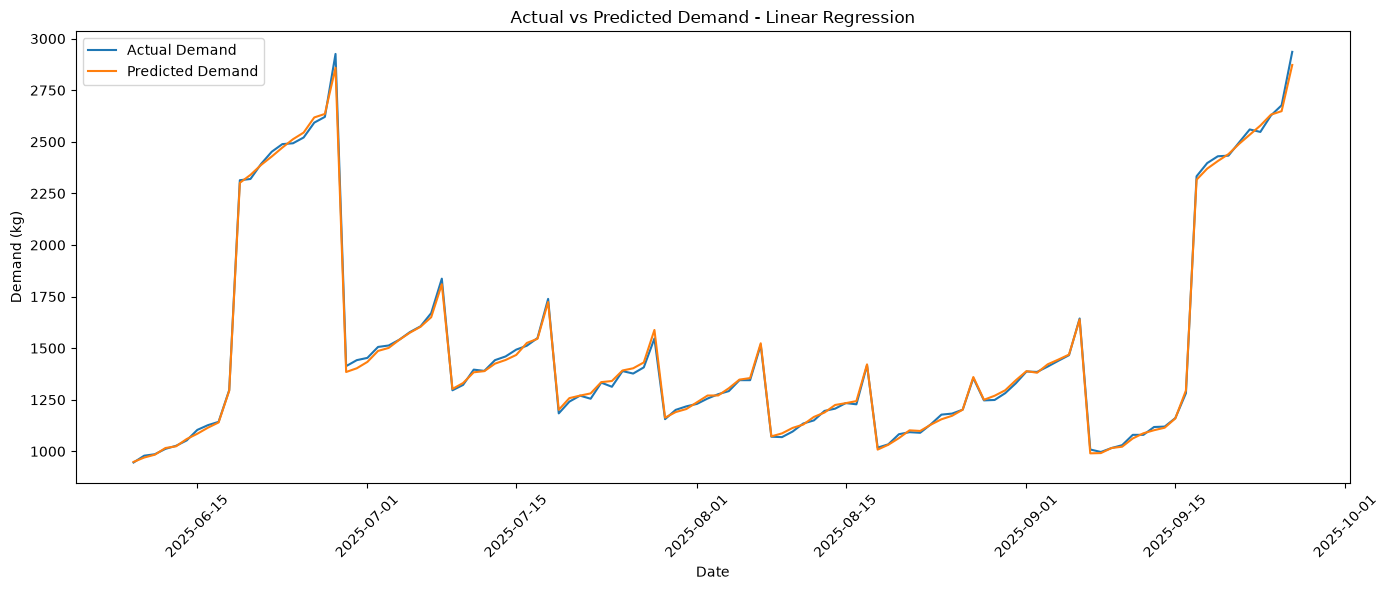

In [192]:
results_df = pd.DataFrame(
    {
        "date": date_test.values,
        "actual": y_test.values,
        "predicted": best_test_pred
    }
)

results_df = results_df.sort_values(
    "date"
)

daily_results = (
    results_df
    .groupby("date")
    [["actual", "predicted"]]
    .mean()
    .reset_index()
)


plt.figure(figsize=(14, 6))

plt.plot(
    daily_results["date"],
    daily_results["actual"],
    label="Actual Demand"
)

plt.plot(
    daily_results["date"],
    daily_results["predicted"],
    label="Predicted Demand"
)

plt.title(
    f"Actual vs Predicted Demand - {best_model_name}"
)

plt.xlabel("Date")

plt.ylabel("Demand (kg)")

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

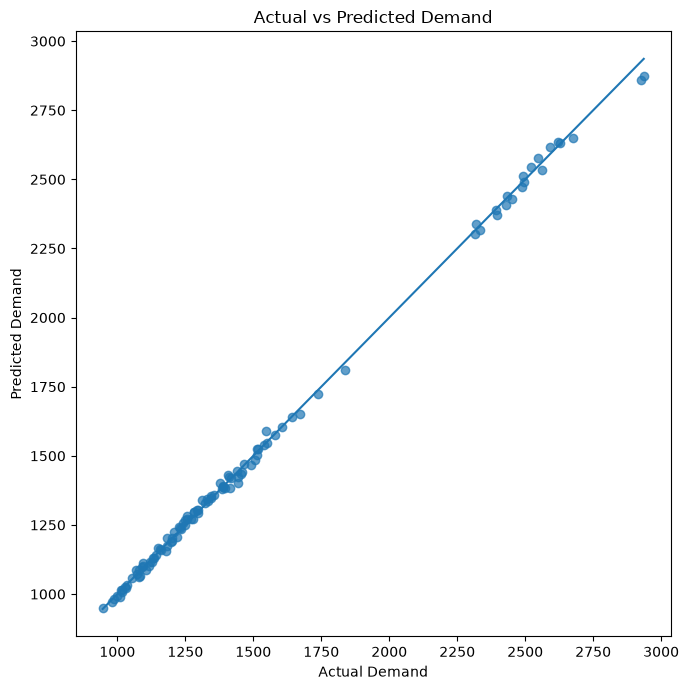

In [193]:
plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    best_test_pred,
    alpha=0.7
)

minimum = min(
    y_test.min(),
    best_test_pred.min()
)

maximum = max(
    y_test.max(),
    best_test_pred.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum]
)

plt.title(
    "Actual vs Predicted Demand"
)

plt.xlabel(
    "Actual Demand"
)

plt.ylabel(
    "Predicted Demand"
)

plt.tight_layout()

plt.show()

,actual,predicted
location,,
Delhi,2528.05,2519.497048
Faridabad,1283.60,1287.054602
Ghaziabad,1459.90,1453.537296
Gurugram,1331.60,1350.037039
Meerut,1384.00,1390.461769
Noida,1555.90,1538.841877
Panipat,1136.70,1132.464467
Rohtak,1078.35,1073.978345
Sonipat,1180.30,1188.164313


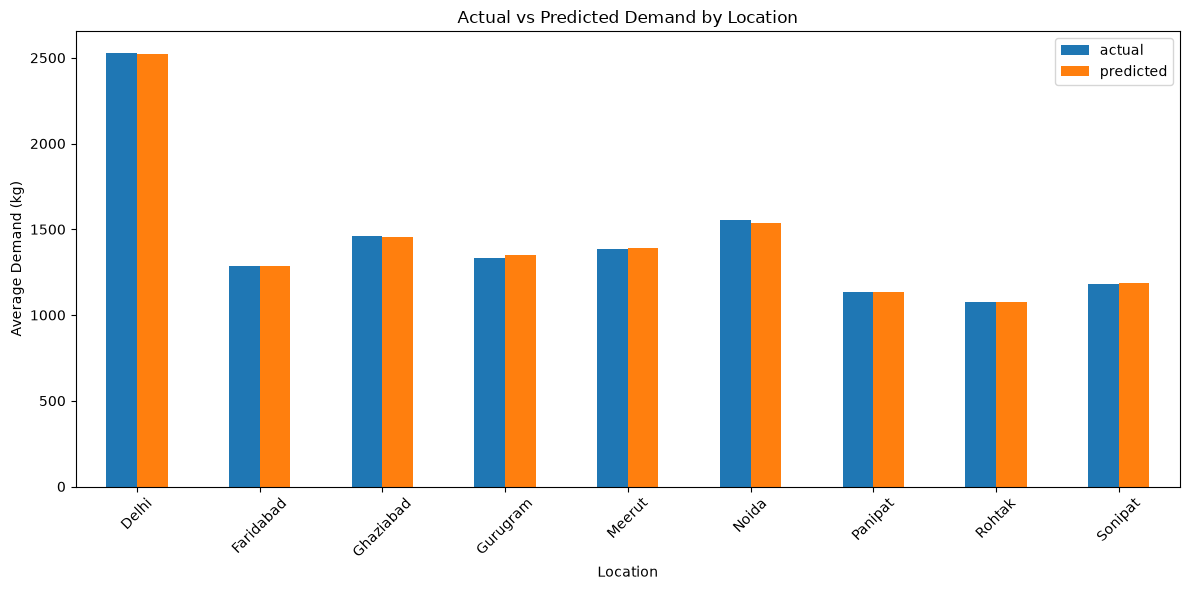

In [194]:
location_results = pd.DataFrame(
    {
        "location": df_model.iloc[
            validation_end:
        ]["location"].values,

        "actual": y_test.values,

        "predicted": best_test_pred
    }
)

location_comparison = (
    location_results
    .groupby("location")
    [["actual", "predicted"]]
    .mean()
)

display(
    location_comparison
)

location_comparison.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title(
    "Actual vs Predicted Demand by Location"
)

plt.xlabel(
    "Location"
)

plt.ylabel(
    "Average Demand (kg)"
)

plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.show()

In [195]:
error_analysis = pd.DataFrame(
    {
        "date": date_test.values,
        "actual": y_test.values,
        "predicted": best_test_pred
    }
)

error_analysis["error"] = (
    error_analysis["actual"]
    -
    error_analysis["predicted"]
)

error_analysis["absolute_error"] = (
    error_analysis["error"]
    .abs()
)

error_analysis["percentage_error"] = np.where(
    error_analysis["actual"] != 0,

    (
        error_analysis["absolute_error"]
        /
        error_analysis["actual"]
    ) * 100,

    np.nan
)

display(
    error_analysis.head()
)

,date,actual,predicted,error,absolute_error,percentage_error
0,2025-06-09,946,948.897294,-2.897294,2.897294,0.306268
1,2025-06-10,979,970.043610,8.956390,8.956390,0.914851
2,2025-06-11,986,983.787650,2.212350,2.212350,0.224376
3,2025-06-12,1012,1016.200890,-4.200890,4.200890,0.415108
4,2025-06-13,1027,1024.490773,2.509227,2.509227,0.244326


In [196]:
largest_errors = (
    error_analysis
    .sort_values(
        "absolute_error",
        ascending=False
    )
    .head(10)
)

display(
    largest_errors
)

,date,actual,predicted,error,absolute_error,percentage_error
19,2025-06-28,2926,2859.041462,66.958538,66.958538,2.288398
109,2025-09-26,2936,2872.581552,63.418448,63.418448,2.160029
49,2025-07-28,1547,1588.306249,-41.306249,41.306249,2.670087
21,2025-06-30,1442,1402.575750,39.424250,39.424250,2.733998
106,2025-09-23,2548,2578.701240,-30.701240,30.701240,1.204915
108,2025-09-25,2677,2648.613246,28.386754,28.386754,1.060394
20,2025-06-29,1413,1384.641368,28.358632,28.358632,2.006980
45,2025-07-24,1313,1340.909777,-27.909777,27.909777,2.125649
29,2025-07-08,1837,1810.029400,26.970600,26.970600,1.468187
101,2025-09-18,2397,2370.036502,26.963498,26.963498,1.124885


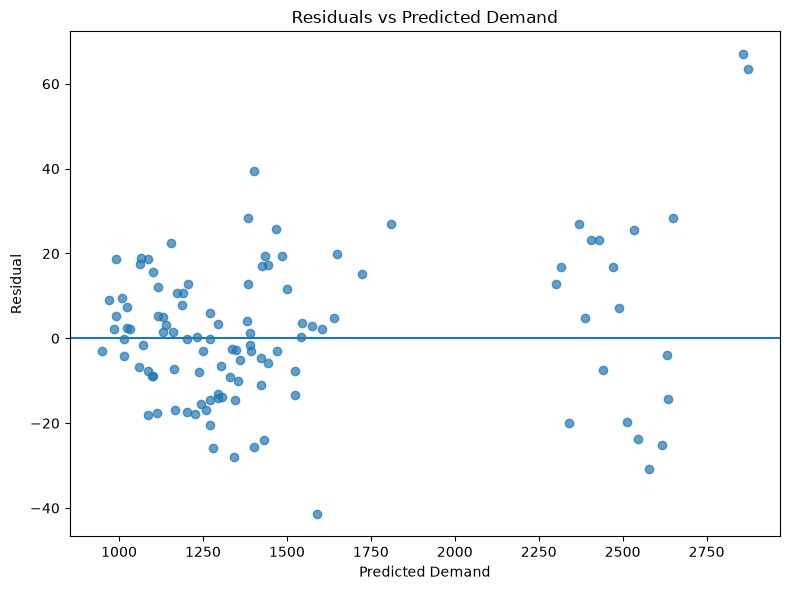

In [197]:
plt.figure(figsize=(8, 6))

plt.scatter(
    error_analysis["predicted"],
    error_analysis["error"],
    alpha=0.7
)

plt.axhline(
    0
)

plt.title(
    "Residuals vs Predicted Demand"
)

plt.xlabel(
    "Predicted Demand"
)

plt.ylabel(
    "Residual"
)

plt.tight_layout()

plt.show()

In [198]:
X_final_train = pd.concat(
    [
        X_train,
        X_val
    ]
)

y_final_train = pd.concat(
    [
        y_train,
        y_val
    ]
)


if best_model_name == "Linear Regression":

    final_model = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "model",
                LinearRegression()
            )
        ]
    )


elif best_model_name == "XGBoost":

    final_model = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "model",
                XGBRegressor(
                    n_estimators=300,
                    learning_rate=0.05,
                    max_depth=4,
                    min_child_weight=5,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    reg_alpha=0.1,
                    reg_lambda=1.0,
                    random_state=RANDOM_STATE,
                    objective="reg:squarederror",
                    n_jobs=-1
                )
            )
        ]
    )


final_model.fit(
    X_final_train,
    y_final_train
)

print(
    "Final model trained on Train + Validation data."
)

Final model trained on Train + Validation data.


In [199]:
final_test_pred = final_model.predict(
    X_test
)

final_test_metrics = evaluate_model(
    y_test,
    final_test_pred
)

print(
    "Final Test Metrics:"
)

print(
    final_test_metrics
)

Final Test Metrics:
{'MAE': 12.565584357904134, 'RMSE': np.float64(16.507149872773088), 'R2': 0.9989835432280719, 'MAPE': np.float64(0.8229352016420298)}


In [200]:
if best_model_name == "XGBoost":

    fitted_preprocessor = final_model.named_steps[
        "preprocessor"
    ]

    fitted_xgb = final_model.named_steps[
        "model"
    ]

    feature_names = (
        fitted_preprocessor
        .get_feature_names_out()
    )

    importance_df = pd.DataFrame(
        {
            "Feature": feature_names,
            "Importance": fitted_xgb.feature_importances_
        }
    )

    importance_df = (
        importance_df
        .sort_values(
            "Importance",
            ascending=False
        )
    )

    display(
        importance_df.head(20)
    )

else:

    print(
        "Feature importance visualization is only shown for XGBoost."
    )

Feature importance visualization is only shown for XGBoost.


In [201]:
if best_model_name == "XGBoost":

    top_features = (
        importance_df
        .head(20)
        .sort_values(
            "Importance"
        )
    )

    plt.figure(
        figsize=(10, 8)
    )

    plt.barh(
        top_features["Feature"],
        top_features["Importance"]
    )

    plt.title(
        "Top 20 Feature Importances"
    )

    plt.xlabel(
        "Importance"
    )

    plt.tight_layout()

    plt.show()

In [202]:
MODEL_PATH = (
    "wheat_demand_forecasting_model.joblib"
)

joblib.dump(
    final_model,
    MODEL_PATH
)

print(
    f"Model saved successfully as: {MODEL_PATH}"
)

Model saved successfully as: wheat_demand_forecasting_model.joblib


In [203]:
FEATURES_PATH = (
    "wheat_feature_columns.joblib"
)

joblib.dump(
    feature_columns,
    FEATURES_PATH
)

print(
    "Feature columns saved successfully."
)

Feature columns saved successfully.


In [204]:
loaded_model = joblib.load(
    MODEL_PATH
)

print(
    "Model loaded successfully!"
)

print(
    type(loaded_model)
)

Model loaded successfully!
<class 'sklearn.pipeline.Pipeline'>


In [205]:
def create_future_features(
    historical_df,
    location,
    crop,
    future_date,
    price_per_kg,
    temperature_c,
    rainfall_mm,
    market_arrivals_kg,
    festival_flag
):

    future_date = pd.to_datetime(
        future_date
    )

    history = historical_df[
        (
            historical_df["location"] == location
        )
        &
        (
            historical_df["crop"] == crop
        )
        &
        (
            historical_df["date"] < future_date
        )
    ].copy()

    history = history.sort_values(
        "date"
    )

    if len(history) < 30:

        raise ValueError(
            f"Not enough historical data for {location} - {crop}. "
            "At least 30 previous observations are required."
        )

    demand_history = history[
        "demand_kg"
    ].values


    future_row = {
        "location": location,
        "crop": crop,

        "price_per_kg": price_per_kg,
        "temperature_c": temperature_c,
        "rainfall_mm": rainfall_mm,
        "market_arrivals_kg": market_arrivals_kg,
        "festival_flag": festival_flag,

        "year": future_date.year,
        "month": future_date.month,
        "day": future_date.day,

        "day_of_week": future_date.dayofweek,

        "day_of_year": future_date.dayofyear,

        "week_of_year": int(
            future_date.isocalendar().week
        ),

        "quarter": future_date.quarter,

        "is_weekend": int(
            future_date.dayofweek >= 5
        )
    }


    future_row["month_sin"] = np.sin(
        2 * np.pi *
        future_row["month"] / 12
    )

    future_row["month_cos"] = np.cos(
        2 * np.pi *
        future_row["month"] / 12
    )

    future_row["day_of_week_sin"] = np.sin(
        2 * np.pi *
        future_row["day_of_week"] / 7
    )

    future_row["day_of_week_cos"] = np.cos(
        2 * np.pi *
        future_row["day_of_week"] / 7
    )


    for lag in [
        1,
        2,
        3,
        7,
        14,
        30
    ]:

        future_row[
            f"lag_{lag}"
        ] = demand_history[-lag]


    previous_demands = demand_history


    future_row[
        "rolling_mean_7"
    ] = np.mean(
        previous_demands[-7:]
    )

    future_row[
        "rolling_mean_14"
    ] = np.mean(
        previous_demands[-14:]
    )

    future_row[
        "rolling_mean_30"
    ] = np.mean(
        previous_demands[-30:]
    )


    future_row[
        "rolling_std_7"
    ] = np.std(
        previous_demands[-7:],
        ddof=1
    )

    future_row[
        "rolling_std_30"
    ] = np.std(
        previous_demands[-30:],
        ddof=1
    )


    future_df = pd.DataFrame(
        [future_row]
    )

    future_df = future_df[
        feature_columns
    ]

    return future_df

In [206]:
future_features = create_future_features(
    historical_df=df,

    location="Delhi",

    crop="Wheat",

    future_date="2026-09-10",

    price_per_kg=30.0,

    temperature_c=25.0,

    rainfall_mm=2.0,

    market_arrivals_kg=950,

    festival_flag=0
)

display(
    future_features
)

,location,crop,price_per_kg,temperature_c,rainfall_mm,market_arrivals_kg,festival_flag,year,month,day,day_of_week,day_of_year,week_of_year,quarter,is_weekend,month_sin,month_cos,day_of_week_sin,day_of_week_cos,lag_1,lag_2,lag_3,lag_7,lag_14,lag_30,rolling_mean_7,rolling_mean_14,rolling_mean_30,rolling_std_7,rolling_std_30
0,Delhi,Wheat,30.0,25.0,2.0,950,0,2026,9,10,3,253,37,3,0,-1.0,-1.836970e-16,0.433884,-0.900969,2936,2677,2628,2433,2521,2293,2611.285714,2578.571429,2518.533333,164.072864,173.035323


In [207]:
future_prediction = loaded_model.predict(
    future_features
)

predicted_demand = max(
    0,
    future_prediction[0]
)

print(
    "Predicted Wheat Demand:",
    round(
        predicted_demand,
        2
    ),
    "kg"
)

Predicted Wheat Demand: 912.14 kg


In [208]:
def predict_demand(
    location,
    crop,
    future_date,
    price_per_kg,
    temperature_c,
    rainfall_mm,
    market_arrivals_kg,
    festival_flag
):

    future_features = create_future_features(

        historical_df=df,

        location=location,

        crop=crop,

        future_date=future_date,

        price_per_kg=price_per_kg,

        temperature_c=temperature_c,

        rainfall_mm=rainfall_mm,

        market_arrivals_kg=market_arrivals_kg,

        festival_flag=festival_flag
    )


    prediction = loaded_model.predict(
        future_features
    )[0]


    prediction = max(
        0,
        prediction
    )


    return prediction


print(
    "Prediction function created successfully."
)

Prediction function created successfully.


In [209]:
latest_market_data = (
    df.sort_values("date")
    .groupby(
        ["location", "crop"]
    )
    .tail(1)
)

latest_market_data = (
    latest_market_data
    .reset_index(drop=True)
)

display(
    latest_market_data[
        [
            "location",
            "crop",
            "date",
            "price_per_kg",
            "temperature_c",
            "rainfall_mm",
            "market_arrivals_kg",
            "festival_flag"
        ]
    ]
)

,location,crop,date,price_per_kg,temperature_c,rainfall_mm,market_arrivals_kg,festival_flag
0,Noida,Wheat,2025-07-08,35.0,31.0,0.0,2231,1
1,Ghaziabad,Wheat,2025-07-18,34.5,31.3,1.0,2105,1
2,Gurugram,Wheat,2025-07-28,36.7,31.2,0.0,1908,1
3,Faridabad,Wheat,2025-08-07,34.4,30.6,0.0,1856,1
4,Sonipat,Wheat,2025-08-17,33.3,29.7,0.8,1711,1
5,Panipat,Wheat,2025-08-27,32.4,28.8,0.0,1632,1
6,Meerut,Wheat,2025-09-06,33.6,27.6,0.0,1985,1
7,Rohtak,Wheat,2025-09-16,32.5,26.7,0.0,1566,1
8,Delhi,Wheat,2025-09-26,33.9,26.0,0.0,3597,1


In [210]:
future_date = "2026-09-10"

locations = sorted(
    df["location"].unique()
)

all_predictions = []


for location in locations:

    latest_row = latest_market_data[
        (
            latest_market_data["location"]
            == location
        )
        &
        (
            latest_market_data["crop"]
            == "Wheat"
        )
    ]


    if len(latest_row) == 0:

        continue


    latest_row = latest_row.iloc[0]


    prediction = predict_demand(

        location=location,

        crop="Wheat",

        future_date=future_date,

        price_per_kg=latest_row["price_per_kg"],

        temperature_c=latest_row["temperature_c"],

        rainfall_mm=latest_row["rainfall_mm"],

        market_arrivals_kg=latest_row[
            "market_arrivals_kg"
        ],

        festival_flag=latest_row[
            "festival_flag"
        ]
    )


    all_predictions.append(
        {
            "location": location,
            "crop": "Wheat",
            "predicted_demand_kg": round(
                prediction,
                2
            )
        }
    )


predictions_df = pd.DataFrame(
    all_predictions
)

display(
    predictions_df
)

,location,crop,predicted_demand_kg
0,Delhi,Wheat,2812.23
1,Faridabad,Wheat,1524.45
2,Ghaziabad,Wheat,1708.82
3,Gurugram,Wheat,1581.11
4,Meerut,Wheat,1623.20
5,Noida,Wheat,1795.67
6,Panipat,Wheat,1365.26
7,Rohtak,Wheat,1305.23
8,Sonipat,Wheat,1428.38


In [211]:
routing_df = predictions_df[
    predictions_df[
        "predicted_demand_kg"
    ] > 0
].copy()


print(
    "Locations with Positive Demand:"
)

display(
    routing_df
)

Locations with Positive Demand:


,location,crop,predicted_demand_kg
0,Delhi,Wheat,2812.23
1,Faridabad,Wheat,1524.45
2,Ghaziabad,Wheat,1708.82
3,Gurugram,Wheat,1581.11
4,Meerut,Wheat,1623.20
5,Noida,Wheat,1795.67
6,Panipat,Wheat,1365.26
7,Rohtak,Wheat,1305.23
8,Sonipat,Wheat,1428.38


In [212]:
OUTPUT_PATH = (
    "predicted_demand_for_routing.csv"
)

routing_df.to_csv(
    OUTPUT_PATH,
    index=False
)

print(
    f"Routing file exported successfully: {OUTPUT_PATH}"
)

display(
    routing_df
)

Routing file exported successfully: predicted_demand_for_routing.csv


,location,crop,predicted_demand_kg
0,Delhi,Wheat,2812.23
1,Faridabad,Wheat,1524.45
2,Ghaziabad,Wheat,1708.82
3,Gurugram,Wheat,1581.11
4,Meerut,Wheat,1623.20
5,Noida,Wheat,1795.67
6,Panipat,Wheat,1365.26
7,Rohtak,Wheat,1305.23
8,Sonipat,Wheat,1428.38


In [213]:
leakage_checklist = {

    "Future demand used as feature":
        "NO",

    "Rolling features use current demand":
        "NO - shift(1) is used",

    "Train/Test split chronological":
        "YES",

    "Random train_test_split used":
        "NO",

    "TimeSeriesSplit shuffles data":
        "NO",

    "Preprocessing fitted inside training pipeline":
        "YES",

    "Test data used for model selection":
        "NO - validation performance is used",

    "Future lag values invented":
        "NO - latest historical demand is used",

    "Zero demand automatically removed":
        "NO"
}


for item, result in leakage_checklist.items():

    print(
        f"{item}: {result}"
    )

Future demand used as feature: NO
Rolling features use current demand: NO - shift(1) is used
Train/Test split chronological: YES
Random train_test_split used: NO
TimeSeriesSplit shuffles data: NO
Preprocessing fitted inside training pipeline: YES
Test data used for model selection: NO - validation performance is used
Future lag values invented: NO - latest historical demand is used
Zero demand automatically removed: NO
